In [18]:
from c3po.tables.dev_tables import C3POStorage

model_name = "rat_hpc_lineartrack_16d"
model_name = "rat_hpc_lineartrack_c20z32"
model_name = "rat_hpc_lineartrack_c20z20_model2"
# model_name = "rat_hpc_lineartrack_c20z20_model2_trainRuns"
model_name = "rat_hpc_lineartrack_c20z20_model2_trainRuns_onlySmallNegSamples"
model_name = "rat_hpc_lineartrack_c20z20_model3"
# model_name = "rat_hpc_lineartrack_c8z20_model3"

model_key = {"model_name": model_name}
(C3POStorage & model_key).fetch1("rate_args")

{'rate_model': 'bilinear'}

In [9]:
key = {
    "nwb_file_name": "Wallie20220912_.nwb",
    "waveform_features_group_name": "10_lineartrack",
}

In [12]:
from spyglass.decoding.v1.clusterless import UnitWaveformFeaturesGroup
from spyglass.decoding.v1.c3po import MarksGroup, Model, ModelSelection, ModelParams, TrainingParams
import numpy as np

group_name = "10_lineartrack_wf_norm1000"
nwb_file_name = "Wallie20220912_.nwb"

group_key = {
    "nwb_file_name": nwb_file_name,
    "marks_group_name": group_name,
}
marks, mark_times = MarksGroup().fetch_marks(group_key)
print("number of events: ", marks.shape[0])
print(f"feature dimension: {marks.shape[1]-1} features + 1 (shank id)")
num_shanks = np.max(marks[:, -1]) + 1
delta_t = np.median(np.diff(mark_times))
mua_rate = 1 / delta_t

print(f"number of shanks: {num_shanks}")
print(f"MUA rate: {mua_rate}")

Max shank features: 4, number of shanks: 30
number of events:  747650
feature dimension: 4 features + 1 (shank id)
number of shanks: 30.0
MUA rate: 1153.8662998624484


In [13]:
ModelSelection() & group_key

nwb_file_name name of the NWB file,marks_group_name name of the marks group,model_name name of the model architecture,training_params_name name of the training parameters set,training_interval_name descriptive name of this interval list
Wallie20220912_.nwb,10_lineartrack_wf_norm1000,wallie_linear_dim20_10Smooth_v0,wallie_20_dim_v0,10_lineartrack
Wallie20220912_.nwb,10_lineartrack_wf_norm1000,wallie_linear_dim20_noSmooth_v0,wallie_20_dim_v0,10_lineartrack


In [14]:
model_name = "wallie_linear_dim8_noSmooth_v0"
from spyglass.decoding.v1.c3po import ModelParams

# hyperparams
latent_dim = 8
context_dim = 8

# encoder
encoder_widths = [16, 32, 64] # layers of a dense MLP for each shank, with a final output of latent_dim
shank_args = dict(encoder_model="simple", widths=encoder_widths)
encoder_args = dict(
    shank_encoder_params=shank_args,
    encoder_model="multi_shank_v1",
    n_shanks=int(num_shanks),
)


# context
dilations = [1, 2, 4, 8, 16]
dilations = dilations * 2
kernels = [10, 20, 64, 64, 128]
kernels = kernels * 2
smoothing = 10
context_args = dict(
    context_model="wavenet",
    layer_dilations=dilations,
    layer_kernel_size=kernels,
    expanded_dim=64,
    smoothing=smoothing,
    smoothing_decay=0.95,
    categorical=False,
)
if smoothing >1:
    print(f"Smoothing is enabled with a value of {smoothing}, corresponding to a "
          f"timescale of {smoothing/mua_rate*1000:2f}ms.")
else:
    print("Smoothing is disabled.")
context_window = max([d*k for d, k in zip(dilations, kernels)])
context_time = context_window / mua_rate
print(f"Context window is {context_window} samples, corresponding to a timescale of {context_time*1000:.2f}ms.")


rate_args = dict(
    rate_model="sharedSpace",
)

hazard_model = "poisson"

model_params = dict(
    model_name=model_name,
    latent_dim=latent_dim,
    context_dim=context_dim,
    encoder_args=encoder_args,
    context_args=context_args,
    rate_args=rate_args,
    hazard_model=hazard_model,
)

ModelParams().insert1(model_params, skip_duplicates=True)

model_key = {
    "model_name": model_name,
}
ModelParams().get_model(model_key)

Smoothing is enabled with a value of 10, corresponding to a timescale of 8.666515ms.
Context window is 2048 samples, corresponding to a timescale of 1774.90ms.


C3PO(
    # attributes
    encoder_args = {'shank_encoder_params': {'encoder_model': 'simple', 'widths': [16, 32, 64]}, 'encoder_model': 'multi_shank_v1', 'n_shanks': 30}
    context_args = {'context_model': 'wavenet', 'layer_dilations': [1, 2, 4, 8, 16, 1, 2, 4, 8, 16], 'layer_kernel_size': [10, 20, 64, 64, 128, 10, 20, 64, 64, 128], 'expanded_dim': 64, 'smoothing': 10, 'smoothing_decay': 0.95, 'categorical': False}
    rate_args = {'rate_model': 'sharedSpace'}
    distribution = 'poisson'
    latent_dim = 8
    context_dim = 8
    n_neg_samples = 1
    predicted_sequence_length = 1
    context_convolutional = None
    sample_params = None
    return_embeddings_in_call = True
)

In [21]:
from spyglass.common import TaskEpoch

TaskEpoch & key

nwb_file_name name of the NWB file,epoch the session epoch for this task and apparatus(1 based),task_name,camera_name,interval_list_name descriptive name of this interval list,task_environment the environment the animal was in,camera_names list of keys corresponding to entry in CameraDevice
Wallie20220912_.nwb,1,rest,Wallie sleep camera,01_sleep,none,=BLOB=
Wallie20220912_.nwb,2,lineartrack,Wallie run camera,02_lineartrack,none,=BLOB=
Wallie20220912_.nwb,3,rest,Wallie sleep camera,03_sleep,none,=BLOB=
Wallie20220912_.nwb,4,lineartrack,Wallie run camera,04_lineartrack,none,=BLOB=
Wallie20220912_.nwb,5,rest,Wallie sleep camera,05_sleep,none,=BLOB=
Wallie20220912_.nwb,6,lineartrack,Wallie run camera,06_lineartrack,none,=BLOB=
Wallie20220912_.nwb,7,rest,Wallie sleep camera,07_sleep,none,=BLOB=
Wallie20220912_.nwb,8,lineartrack,Wallie run camera,08_lineartrack,none,=BLOB=
Wallie20220912_.nwb,9,rest,Wallie sleep camera,09_sleep,none,=BLOB=
Wallie20220912_.nwb,10,lineartrack,Wallie run camera,10_lineartrack,none,=BLOB=


In [9]:
TrainingParams & "training_params_name LIKE 'wallie%'"

training_params_name name of the training parameters set,sample_length length of each training sample in number of marks,sample_step step size for sampling training data in number of marks,mark_jitter amount of jitter to add to mark times to break ties (in seconds),delta_t_units units to convert delta_t to for training,learning_rate learning rate for training,n_epochs (maximum) number of epochs for training,training_function name of the training function to use,training_params additional parameters for the training function,jax_seed random seed for JAX operations during training
wallie_20_dim_v0,5000,1250,0.0001,ms,0.0003,1000,c3po_annealing,=BLOB=,42
wallie_v0,5000,4000,0.0001,ms,0.0003,1000,c3po_annealing,=BLOB=,42


In [15]:

training_params_name = "wallie_20_dim_v0"
from spyglass.decoding.v1.c3po import TrainingParams

training_params = dict(
    training_params_name=training_params_name,
    sample_length=5000,
    sample_step=5000 //4,
    mark_jitter=1e-4,
    delta_t_units="ms",
    learning_rate=3e-4,
    n_epochs=1000,
    training_function="c3po_annealing",
    training_params=dict(
        initial_batch_size=32,
        initial_n_neg=2,
        buffer_size=8,
        loss_type="contrastive",
        max_n_neg=32,
        min_batch_size=4,
        multi_gpu=False,
        l1_penalty=None,
    ),
    jax_seed=42,
)
from spyglass.decoding.v1.c3po import TrainingParams

TrainingParams().insert1(training_params, skip_duplicates=True)


In [16]:


from spyglass.decoding.v1.c3po import ModelSelection, Model
epoch_interval = "10_lineartrack"
sel_key = {
    "nwb_file_name": nwb_file_name,
    "training_params_name": training_params_name,
    "model_name": model_name,
    "marks_group_name": group_name,
    "training_interval_name": epoch_interval,
}

ModelSelection().insert1(sel_key, skip_duplicates=True)


In [17]:
sel_key

{'nwb_file_name': 'Wallie20220912_.nwb',
 'training_params_name': 'wallie_20_dim_v0',
 'model_name': 'wallie_linear_dim8_noSmooth_v0',
 'marks_group_name': '10_lineartrack_wf_norm1000',
 'training_interval_name': '10_lineartrack'}

In [4]:
from spyglass.decoding.v1.c3po import ModelSelection, Model
ModelSelection() & {"nwb_file_name":"Wallie20220912_.nwb"}

ImportError: cannot import name 'Model' from partially initialized module 'spyglass.decoding.v1.c3po' (most likely due to a circular import) (/home/sambray/Documents/spyglass_dev/spyglass/src/spyglass/decoding/v1/c3po.py)

In [44]:
analysis = (Model & sel_key).fetch_c3po_analysis(checkpoint = None)

[13:57:10][WARNING] Spyglass: Restriction had no effect — no shared attributes found. Please check your restrict() call.
[13:57:10][WARNING] Spyglass: Restriction had no effect — no shared attributes found. Please check your restrict() call.
[13:57:10][WARNING] Spyglass: Restriction had no effect — no shared attributes found. Please check your restrict() call.


x shape (1, 5)


In [45]:
analysis.fit_context_pca()
analysis.embed_context_pca()

In [35]:
# load position data
from spyglass.common import PositionIntervalMap
from spyglass.decoding.v1.core import PositionGroup
from spyglass.position.position_merge import PositionOutput
from spyglass.linearization.v1 import LinearizedPositionV1
from scipy.ndimage import gaussian_filter1d

epoch_key = {
    "nwb_file_name": key["nwb_file_name"],
    "interval_list_name": key["waveform_features_group_name"],
}
pos_interval = (PositionIntervalMap() & epoch_key).fetch1("position_interval_name")
pos_key = {
    "nwb_file_name": key["nwb_file_name"],
    "interval_list_name": pos_interval,
    "trodes_pos_params_name": "single_led_upsampled",
}
pos_merge_id = (PositionOutput.TrodesPosV1() & pos_key).fetch("merge_id")
pos_merge_key = {"pos_merge_id": pos_merge_id[0]}


pos_df = (LinearizedPositionV1() & pos_merge_key).fetch1_dataframe()
pos_times = pos_df.index.values  # - first_mark_time
pos = pos_df.linear_position.values
vel = np.diff(pos_df.linear_position.values)
vel = np.concatenate([vel, [vel[-1]]])
vel = gaussian_filter1d(vel, 11, axis=0, mode="nearest")

# pos_ind = np.digitize(mark_times / 1000, pos_times - first_mark_time) - 1
# mark_pos = pos[pos_ind]
# mark_vel = vel[pos_ind]

# Define position-based intervals
all_running = (np.abs(vel * 500) > 10).astype(int)
right_running = ((vel * 500) > 10).astype(int)
left_running = ((vel * 500) < -10).astype(int)

st = np.where(np.diff(all_running) == 1)[0]
en = np.where(np.diff(all_running) == -1)[0]
if en[0] < st[0]:
    en = en[1:]
all_running_intervals = np.array(
    [[pos_df.index[s], pos_df.index[e]] for s, e in zip(st, en)]
)
st = np.where(np.diff(left_running) == 1)[0]
en = np.where(np.diff(left_running) == -1)[0]
if en[0] < st[0]:
    en = en[1:]
left_running_intervals = np.array(
    [[pos_df.index[s], pos_df.index[e]] for s, e in zip(st, en)]
)

st = np.where(np.diff(right_running) == 1)[0]
en = np.where(np.diff(right_running) == -1)[0]
if en[0] < st[0]:
    en = en[1:]
right_running_intervals = np.array(
    [[pos_df.index[s], pos_df.index[e]] for s, e in zip(st, en)]
)

/home/sambray/.local/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-franklab-novela': 
 ndx-franklab-novela defines CameraDevice.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel. 
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extension_ns_name=ns_name,
/home/sambray/.local/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)
/home/sambray/.local/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a Dev

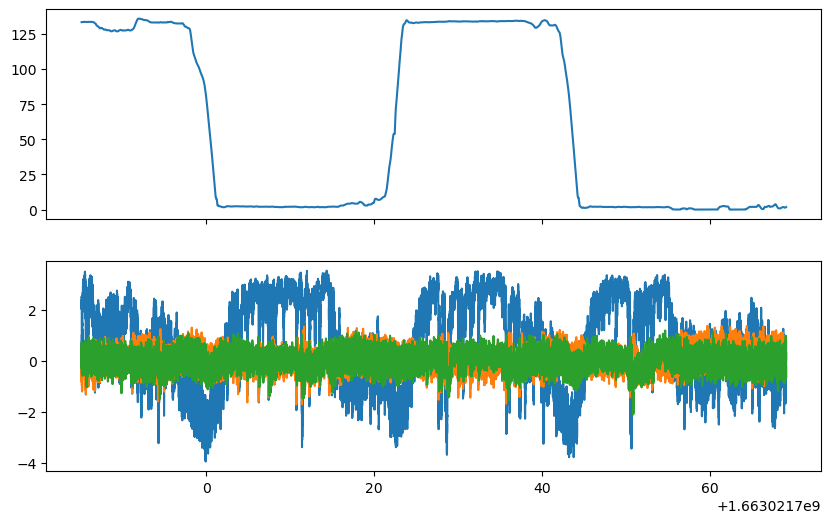

In [46]:
st = 100000
ind = slice(st, st+50000)

import matplotlib.pyplot as plt
fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax[1].plot(analysis.t[ind], analysis.c_pca[ind,:3])

ind_pos = np.logical_and(pos_times > analysis.t[ind][0], pos_times < analysis.t[ind][-1])
ax[0].plot(pos_times[ind_pos], pos[ind_pos])

In [57]:
import sortingview.views as vv
import os
from matplotlib.colors import to_hex

os.environ["KACHERY_API_KEY"] = "g9UmADRrAGfSPs1RRNKd6DtYTao3WQd2"


color_list = [
    "#1f77b4",
    "#ff7f0e",
    "#2ca02c",
    "#d62728",
    "#9467bd",
    "#8c564b",
    "#e377c2",
    "#7f7f7f",
    "#bcbd22",
    "#17becf",
]

subsample = 1
context_graph = vv.TimeseriesGraph()

c_fig = analysis.c_pca
# c_fig = smooth(c_fig, sigma=int(10), hamming=True)
c_fig = c_fig[::subsample]
t_fig = analysis.t[::subsample]

# c_fig = analysis.c_pca_interp[::subsample]
# t_fig = analysis.t_interp[::subsample]

ind = ~np.any(np.isnan(c_fig), axis=1)
c_fig = c_fig[ind]
t_fig = t_fig[ind]


for i in np.arange(
    3,
):
    context_graph.add_line_series(
        name=f"context pc: {i}",
        t=t_fig,
        y=c_fig[:, i].astype(np.float32),
        width=2,
        color=color_list[i],
    )


context_graph2 = vv.TimeseriesGraph()
for i in np.arange(3, 7):
    context_graph2.add_line_series(
        name=f"context pc: {i}",
        t=t_fig,
        y=c_fig[:, i].astype(np.float32),
        width=2,
        color=color_list[i],
    )


# Speed graph
speed_graph = vv.TimeseriesGraph()
# for angle in trials_df.reach_angle.unique():
#     angle_df = trials_df[trials_df.reach_angle == angle]
#     print(angle_df.size)
#     color = to_hex(plt.cm.hsv((angle + np.pi) / (2 * np.pi)))
#     intervals_ = angle_df.target_on_time.values
#     # intervals_ = [[i, i+.5] for i in intervals_]
#     speed_graph.add_interval_series(
#         name=f"{angle} cue",
#         t_start=intervals_,
#         t_end=intervals_ + 0.05,
#         color=color,
#     )

#     intervals_ = angle_df.go_cue_time.values
#     # intervals_ = [[i, i+.5] for i in intervals_]
#     speed_graph.add_interval_series(
#         name=f"{angle} go",
#         t_start=intervals_,
#         t_end=intervals_ + 1,
#         color=color,
#     )

speed_graph.add_line_series(
    name="lin_pos",
    t=pos_df.index.values,
    y=pos_df.linear_position.values.astype(np.float32),
    color=color_list[0],
    width=2,
)
# speed_graph.add_line_series(
#     name="vel_y",
#     t=behavior_df.index.values,
#     y=behavior_df.hand_vel_y.values.astype(np.float32),
#     color=color_list[1],
#     width=2,
# )

# mua_graph = vv.TimeseriesGraph()
# mua_graph.add_line_series(
#     name="mua",
#     t=pos_df.index.values,
#     y=mua.astype(np.float32),
#     color=color_list[2],
#     width=2,
# )


# ASSEMBLE
context_panels = [
    vv.LayoutItem(speed_graph, stretch=1),

    # vv.LayoutItem(lfp_graph, stretch=1),
    # vv.LayoutItem(mua_graph, stretch=1),
    vv.LayoutItem(context_graph, stretch=3),
    vv.LayoutItem(context_graph2, stretch=3),
]

view = vv.Box(
    direction="horizontal",
    show_titles=True,
    height=8,
    items=[
        vv.LayoutItem(
            vv.Box(
                direction="vertical",
                show_titles=True,
                items=context_panels,
            )
        ),
    ],
)
view.url(label=f"wallie_linear_no_smoothxt")

'https://figurl.org/f?v=npm://@fi-sci/figurl-sortingview@12/dist&d=kachery:franklab.default:sha1:8dacec740d0a147c989fda3095e33526b55d1a29&label=wallie_linear_no_smoothxt&zone=franklab.default'